# Оценка и визуализация

Confusion matrix, ROC, важность признаков (RF). **Запуск после 03 и 04** (`ml_ready.joblib`, `trained_models.joblib`).

Если файлов моделей нет, ноутбук переобучит модели на тех же данных.

**Colab:** [colab_quickstart.ipynb](colab_quickstart.ipynb); при необходимости `%cd /content/water-quality-ee`.

**Для новичков:** расшифровка метрик и графиков — [`docs/ml_metrics_guide.md`](../docs/ml_metrics_guide.md).


### Пояснение для начинающих (первые три кодовые ячейки)

1. **Импорты** — путь к проекту, загрузка сохранённых данных и функций визуализации.
2. **Загрузка + оценка** — читаем `ml_ready.joblib`; если есть `trained_models.joblib`, подставляем готовые модели, иначе **кратко переобучаем** LR и RF на train и считаем метрики на test.
3. **Сводная таблица** — то же `compare_models`, что в ноутбуке 04.

**Инсайт:** цифры здесь должны **совпадать** с 04 при наличии сохранённых моделей и того же `ml_ready.joblib`.

In [1]:
import importlib.util
import os
import subprocess
import sys
from pathlib import Path

def _project_root() -> Path:
    spec = importlib.util.find_spec('data_loader')
    if spec is not None and getattr(spec, 'origin', None):
        cand = Path(spec.origin).resolve().parent.parent
        if (cand / 'data' / 'raw').is_dir() or (cand / 'src' / 'data_loader.py').is_file():
            return cand
    env = os.environ.get('WATER_QUALITY_EE_ROOT', '').strip()
    if env:
        p = Path(env).expanduser().resolve()
        if (p / 'src' / 'data_loader.py').is_file():
            return p
    cwd = Path.cwd().resolve()
    try:
        r = subprocess.run(
            ['git', 'rev-parse', '--show-toplevel'],
            cwd=cwd, capture_output=True, text=True, timeout=15,
        )
        if r.returncode == 0 and r.stdout.strip():
            p = Path(r.stdout.strip()).resolve()
            if (p / 'src' / 'data_loader.py').is_file():
                return p
    except (FileNotFoundError, OSError, subprocess.TimeoutExpired):
        pass
    for root in [cwd, *list(cwd.parents)[:28]]:
        if (root / 'src' / 'data_loader.py').is_file():
            return root
    raise RuntimeError('См. 01: pip install -e . или корректный WATER_QUALITY_EE_ROOT.')

if importlib.util.find_spec('data_loader') is None:
    sys.path.insert(0, str(_project_root() / 'src'))

import data_loader
ROOT = Path(data_loader.__file__).resolve().parent.parent

import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from evaluate import (
    evaluate_model,
    compare_models,
    plot_confusion_matrix,
    plot_roc_curve,
    plot_feature_importance,
)

In [2]:
data_path = ROOT / 'data' / 'processed' / 'ml_ready.joblib'
models_path = ROOT / 'data' / 'processed' / 'trained_models.joblib'

if not data_path.exists():
    raise FileNotFoundError(f'Нет {data_path}. Запустите 03_preprocessing.ipynb')

b = joblib.load(data_path)
X_train, X_test = b['X_train'], b['X_test']
y_train, y_test = b['y_train'], b['y_test']
feature_names = b['feature_names']

if models_path.exists():
    pack = joblib.load(models_path)
    lr, rf = pack['lr'], pack['rf']
else:
    lr = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42)
    lr.fit(X_train, y_train)
    rf = RandomForestClassifier(
        n_estimators=200, max_depth=12, class_weight='balanced',
        random_state=42, n_jobs=-1,
    )
    rf.fit(X_train, y_train)

res_lr = evaluate_model(lr, X_test, y_test, model_name='Logistic Regression')
res_rf = evaluate_model(rf, X_test, y_test, model_name='Random Forest')


Модель: Logistic Regression
               precision    recall  f1-score   support

Нарушение (0)       0.43      0.79      0.56      1671
    Норма (1)       0.97      0.86      0.91     12219

     accuracy                           0.85     13890
    macro avg       0.70      0.82      0.73     13890
 weighted avg       0.90      0.85      0.87     13890

ROC-AUC: 0.8998



Модель: Random Forest
               precision    recall  f1-score   support

Нарушение (0)       0.83      0.91      0.87      1671
    Норма (1)       0.99      0.97      0.98     12219

     accuracy                           0.97     13890
    macro avg       0.91      0.94      0.92     13890
 weighted avg       0.97      0.97      0.97     13890

ROC-AUC: 0.9851


In [3]:
compare_models([res_lr, res_rf])

,Accuracy,Precision (нарушение),Recall (нарушение),F1 (нарушение),ROC-AUC
Модель,,,,,
Logistic Regression,0.8496,0.4314,0.7864,0.5571,0.8998
Random Forest,0.9669,0.8303,0.9108,0.8687,0.9851


## Confusion matrices

### Пояснение для начинающих
- **Матрица ошибок** 2×2: факт (строки) vs предсказание (столбцы).
- Для класса **нарушение (0)** важна ячейка **false negative**: вода плохая, а модель сказала «норма».

### Результат раздела (инсайт)
Наглядно видно, «где модель лжёт» чаще — полезно для презентации и курсовой.

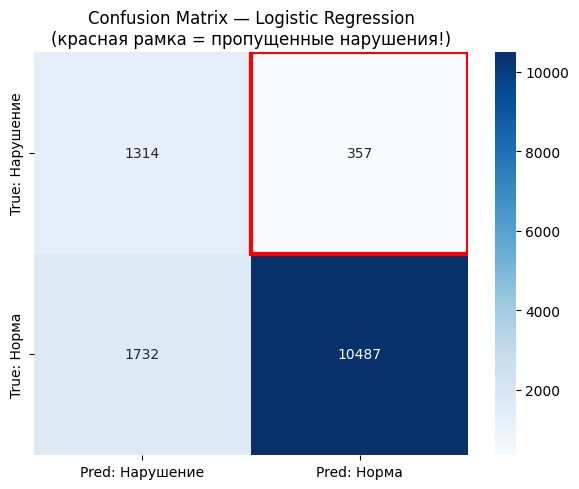

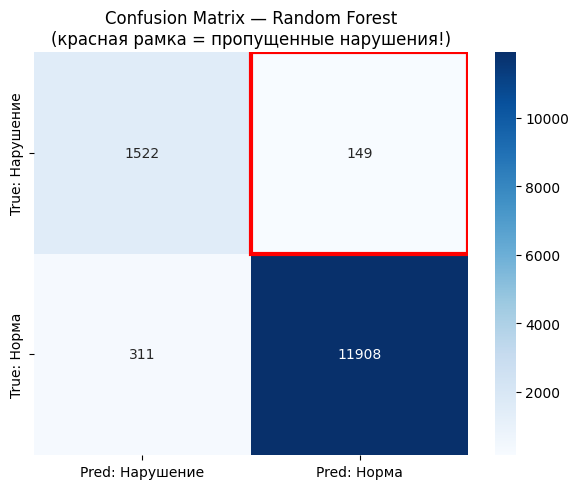

In [4]:
plot_confusion_matrix(y_test, res_lr['y_pred'], model_name='Logistic Regression')
plot_confusion_matrix(y_test, res_rf['y_pred'], model_name='Random Forest')

## ROC (красная рамка в CM — пропущенные нарушения = FN)

### Пояснение для начинающих
- **ROC-кривая** показывает компромисс между долей найденных нарушений и долей ложных тревог при переборе порога вероятности.
- **AUC** — интегральная оценка качества ранжирования; чем выше, тем лучше модель отделяет классы.

### Результат раздела (инсайт)
Сравнение LR и RF на одном графике; RF обычно выше по AUC на этих признаках.

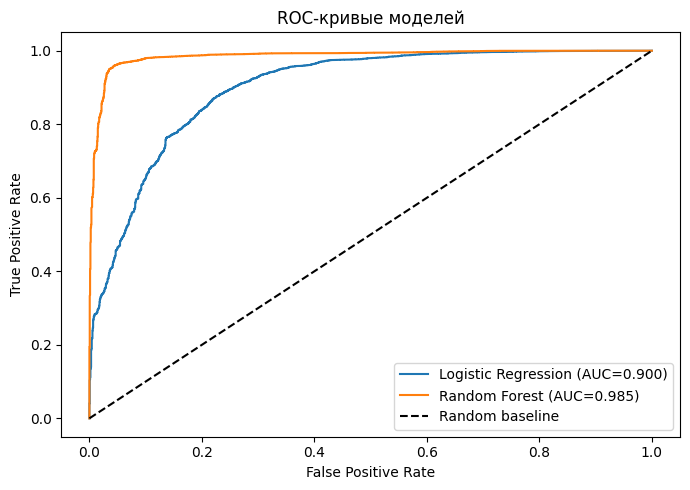

In [5]:
plot_roc_curve([res_lr, res_rf])

## Важность признаков (Random Forest)

### Пояснение для начинающих
- Random Forest для каждого признака считает, **насколько он в среднем уменьшал ошибку** при разбиениях деревьев (упрощённо: «насколько часто и сильно использовали»).
- Это **не причинность**: высокий вес ≠ доказанное влияние на здоровье.

### Результат раздела (инсайт)
Список топ-признаков для обсуждения в отчёте и идей для следующего EDA.

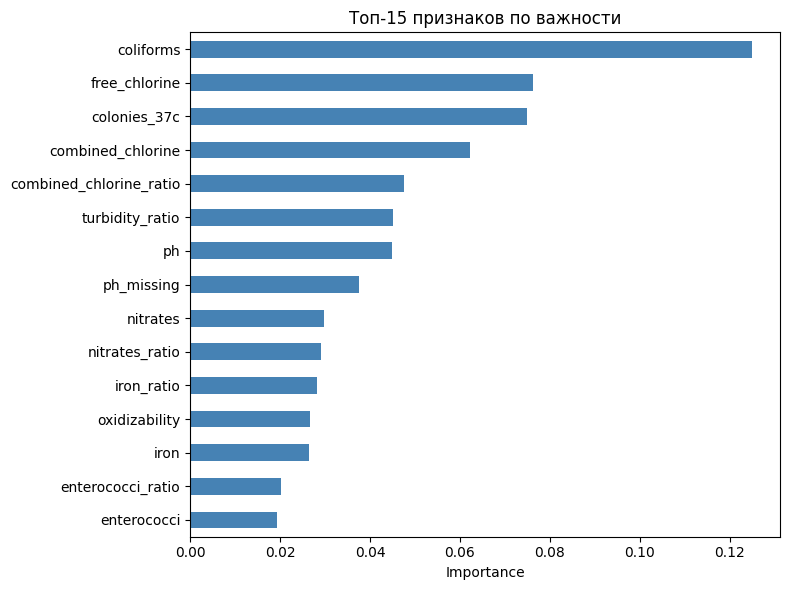

In [6]:
plot_feature_importance(rf, feature_names, top_n=15)

## Per-domain метрики (AI Act Art 15, disaggregated accuracy)

Тот же обученный `rf` и `lr` — переоценка **по каждому домену** без переобучения. Цель — увидеть, где
модель систематически слабее. Домен для каждой строки `X_test` восстанавливается из one-hot столбцов
`domain_*`, созданных в `encode_categoricals` (`src/features.py`). Это срез, требуемый AI Act Art 15
("accuracy across relevant subgroups") и задокументированный в `docs/model_card.md` §7.


In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

_domain_cols = [c for c in X_test.columns if c.startswith('domain_')]
if not _domain_cols:
    raise RuntimeError('Нет one-hot столбцов domain_* в X_test — невозможно сделать per-domain срез.')

# impute_and_scale возвращает X_test с reset integer index; y_test держит исходный индекс.
# Работаем по positional индексам (0..n-1) — безопасно при любых несоответствиях индексов.
_domain_arr = X_test[_domain_cols].idxmax(axis=1).str.replace('domain_', '', regex=False)
_y_test_arr = np.asarray(y_test)

print('Распределение test по доменам:')
print(pd.Series(_domain_arr.values).value_counts())


In [ ]:
def _per_domain_table(model, model_name):
    y_prob_all = model.predict_proba(X_test)[:, 1]
    y_pred_all = model.predict(X_test)
    domain_values = _domain_arr.values
    rows = []
    for dom in sorted(pd.Series(domain_values).unique()):
        mask = (domain_values == dom)
        if mask.sum() == 0:
            continue
        y_t = _y_test_arr[mask]
        y_p = y_pred_all[mask]
        y_pr = y_prob_all[mask]
        rep = classification_report(
            y_t, y_p,
            target_names=['Нарушение (0)', 'Норма (1)'],
            output_dict=True, zero_division=0,
        )
        try:
            auc = roc_auc_score(y_t, y_pr) if len(np.unique(y_t)) > 1 else float('nan')
        except Exception:
            auc = float('nan')
        rows.append({
            'Model': model_name,
            'Domain': dom,
            'n': int(mask.sum()),
            'Recall_0': round(rep['Нарушение (0)']['recall'], 3),
            'Precision_0': round(rep['Нарушение (0)']['precision'], 3),
            'F1_0': round(rep['Нарушение (0)']['f1-score'], 3),
            'Accuracy': round(rep['accuracy'], 3),
            'ROC_AUC': round(auc, 3) if auc == auc else float('nan'),
        })
    return pd.DataFrame(rows)

_tbl = pd.concat([
    _per_domain_table(lr, 'Logistic Regression'),
    _per_domain_table(rf, 'Random Forest'),
], ignore_index=True)
_tbl


### Per-domain confusion matrices (класс 0 = нарушение)

Визуально: какие домены страдают ложноположительными/ложноотрицательными сильнее. Критерий для
обсуждения в `docs/terviseamet_inquiry.md` — где модель хуже всего и какие дополнительные контекстные
данные могли бы это поправить.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

_domains = sorted(pd.Series(_domain_arr.values).unique())
_models = [('Logistic Regression', lr), ('Random Forest', rf)]

fig, axes = plt.subplots(len(_models), len(_domains), figsize=(4 * len(_domains), 4 * len(_models)))
axes = np.atleast_2d(axes)

for row, (name, model) in enumerate(_models):
    y_pred_all = model.predict(X_test)
    for col, dom in enumerate(_domains):
        mask = (_domain_arr.values == dom)
        if mask.sum() == 0:
            continue
        y_t = _y_test_arr[mask]
        y_p = y_pred_all[mask]
        cm = confusion_matrix(y_t, y_p, labels=[0, 1])
        ax = axes[row][col]
        sns.heatmap(
            cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Pred: 0', 'Pred: 1'],
            yticklabels=['True: 0', 'True: 1'],
            ax=ax,
        )
        ax.set_title(f'{name} — {dom} (n={int(mask.sum())})')

plt.tight_layout()
plt.show()


### Per-year breakdown на тестовой выборке

Для временного среза (train ≤ 2024 в `03_preprocessing` случайный; если в будущем перейдёте на
temporal split — именно этот срез становится критичным). Показывает, держится ли качество модели
на свежих данных (2025, 2026).


In [ ]:
_year_col = 'year' if 'year' in X_test.columns else None

if _year_col is None:
    print('Столбец year отсутствует в X_test — срез по годам пропущен.')
    _year_tbl = None
else:
    year_values = X_test[_year_col].values
    rows = []
    for yr in sorted(pd.Series(year_values).unique()):
        mask = (year_values == yr)
        if mask.sum() == 0:
            continue
        y_t = _y_test_arr[mask]
        for name, model in (('Logistic Regression', lr), ('Random Forest', rf)):
            y_p = model.predict(X_test)[mask]
            y_pr = model.predict_proba(X_test)[:, 1][mask]
            rep = classification_report(
                y_t, y_p,
                target_names=['Нарушение (0)', 'Норма (1)'],
                output_dict=True, zero_division=0,
            )
            try:
                auc = roc_auc_score(y_t, y_pr) if len(np.unique(y_t)) > 1 else float('nan')
            except Exception:
                auc = float('nan')
            rows.append({
                'Model': name,
                'Year': int(yr),
                'n': int(mask.sum()),
                'Recall_0': round(rep['Нарушение (0)']['recall'], 3),
                'Precision_0': round(rep['Нарушение (0)']['precision'], 3),
                'ROC_AUC': round(auc, 3) if auc == auc else float('nan'),
            })
    _year_tbl = pd.DataFrame(rows)
    _year_tbl
